In [1]:
import re
import colorsys

import pandas as pd
import numpy as np
import pingouin as pg
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import statsmodels.formula.api as smf
import seaborn as sns
from collections import Counter
from statsmodels.stats.multitest import multipletests
from matplotlib.patches import Patch
from matplotlib.lines import Line2D
from pathlib import Path


from complexity_statistics import NON_METRICS_COLUMNS
from resources.helper_functions import parse_list, parse_doc_id

## Configuration

In [2]:
BASE_DIR = Path().resolve()
OUTPUT_DIR = BASE_DIR / "outputs"
PLOTS_DIR = OUTPUT_DIR / "plots"
PLOTS_DIR.mkdir(parents=True, exist_ok=True)

In [3]:
FAMILIES = {
    "prompt":        {"nodis": ("disability_in_prompt", False),
                      "withdis": ("disability_in_prompt", True)},
    "gender": {"masc": ("genre_auto", "Masc"),
                      "fem": ("genre_auto", "Fem")},
    "model":        {"mistral": ("model", "mistral"),
                      "llama": ("model", "llama"),
                      "qwen": ("model", "qwen")},
    "quantization":  {"awq": ("quant", "awq"),
                      "full": ("quant", "torch")},
}
PARAMS = {"all": None,
          **{p: sel for fam in FAMILIES.values() for p, sel in fam.items()}}

FAMILY_PALETTE = {"prompt": "#1f77b4", "gender": "#ff7f0e",
                  "model": "#2ca02c", "quantization": "#d62728"}


def _shades_of(base, n):
    """n distinguishable shades of `base`, spread dark -> light in HLS, so
    members of one family share its hue but stay easy to tell apart."""
    h, l, s = colorsys.rgb_to_hls(*mcolors.to_rgb(base))
    lights = [l] if n == 1 else np.linspace(max(0.30, l * 0.72),
                                            min(0.82, l * 1.42), n)
    return [mcolors.to_hex(colorsys.hls_to_rgb(h, lt, s)) for lt in lights]


# each family MEMBER gets its own shade of the family hue ('all' stays grey),
# so grouped plots distinguish members by colour AND hatch by default
PARAM_COLORS = {"all": "#9e9e9e"}
for _fam, _params in FAMILIES.items():
    for _p, _c in zip(_params, _shades_of(FAMILY_PALETTE[_fam], len(_params))):
        PARAM_COLORS[_p] = _c

# ---- Accessible styling shared across every bar chart ----
# Texture is a second, colour-independent channel so categories stay
# distinguishable for colour-blind readers and in grayscale / print.
# It is kept light grey and sparse so it never competes with the data
# labels, which additionally get a white halo (LABEL_BBOX) to stay legible
# on top of any fill or hatch.
plt.rcParams["hatch.linewidth"] = 0.6
HATCH_COLOR = "#9e9e9e"          # light grey: never merges with black labels
LABEL_BBOX = dict(boxstyle="round,pad=0.15", fc="white", ec="none", alpha=0.78)

# one texture per parameter value. Families reuse a small set of patterns,
# but no two values that ever appear in the same plot share one.
PARAM_HATCH = {
    "all": "",
    "nodis": "//",   "withdis": "..",                 # prompt
    "masc": "//",    "fem": "..",                      # gender
    "mistral": "//", "llama": "..", "qwen": "xx",      # model
    "awq": "//",     "full": "..",                     # quantization
}

# gender palette: light fills so black labels read cleanly on top
GENDER_STYLE = {
    "Masc": {"color": "#6f9fc8", "hatch": "//", "label": "masculine"},
    "Fem":  {"color": "#f2d488", "hatch": "..", "label": "feminine"},
}

# per grouping-variable texture for the complexity plots
GROUPVAR_HATCH = {"disability_in_prompt": "//", "model": "..", "quant": "xx"}

DISABILITY_CATEGORIES = [
    "handicaps moteurs", "handicaps sensoriels", "handicaps psychiques",
    "handicaps cognitifs", "handicaps mentaux",
    "maladies chroniques évolutives ou invalidantes", "maladies génétiques",
]
RENAME = {
    "handicaps moteurs": "moteurs",
    "handicaps sensoriels": "sensoriels",
    "handicaps psychiques": "psychiques",
    "handicaps cognitifs": "cognitifs",
    "handicaps mentaux": "mentaux",
    "maladies chroniques évolutives ou invalidantes": "mal. chroniques",
    "maladies génétiques": "mal. génétiques",
}
GENDERS = ["Fem", "Masc"]

In [4]:
def make_subsets(df, params=None):
    """One sub-dataframe per parameter subset ('all' + every family value).
    Rebuild after adding indicator columns: subsets are views of df at call time."""
    params = PARAMS if params is None else params
    return {p: (df if sel is None else df[df[sel[0]] == sel[1]])
            for p, sel in params.items()}


def count_pct_table(indicator_cols, subsets, sizes):
    """Count and % of biographies, per parameter subset, for which each
    boolean indicator column is True. Returns (df_counts, df_pct) with
    indicator_cols as rows and the subset names as columns."""
    counts = {p: [int(sub[c].sum()) for c in indicator_cols]
              for p, sub in subsets.items()}
    df_counts = pd.DataFrame(counts, index=indicator_cols)
    df_pct = df_counts.div(pd.Series(sizes), axis=1) * 100
    return df_counts, df_pct


def display_table(df_counts, df_pct, sizes, add_total=True):
    """Human-readable 'count (pct%)' table, with a total row of subset sizes."""
    disp = df_counts.astype(int).astype(str) + " (" + df_pct.round(1).astype(str) + "%)"
    if add_total:
        disp.loc["total"] = [str(sizes[p]) for p in disp.columns]
    return disp


def family_of(param, families=FAMILIES):
    return next((fam for fam, ps in families.items() if param in ps), None)


def family_boundaries(order, families=FAMILIES):
    """Indices (in cell units) where the parameter family changes; used to
    draw separators. For heatmaps use the values directly; for bar plots
    subtract 0.5."""
    return [i + 1 for i in range(len(order) - 1)
            if family_of(order[i], families) != family_of(order[i + 1], families)]


def save_show(fname, rect=None, plots_dir=PLOTS_DIR):
    plt.tight_layout(rect=rect) if rect else plt.tight_layout()
    plt.savefig(plots_dir / fname)
    plt.show()

# Representation analyses

## Import and prepare data

In [5]:
df_rep = pd.read_csv(OUTPUT_DIR / "gender_dis_ner_detection.csv")

COL_LISTS = ['categories', 'disabilities', 'locations', 'locations_raw',
             'names', 'organisations']
for col in COL_LISTS:
    df_rep[f"{col}_parsed"] = df_rep[col].apply(parse_list)

df_rep.head()

,Unnamed: 0,doc_id,bio,genre_auto,Detailed_counter,Detailed_markers,model,prompt_version,disability_in_prompt,run,...,locations,locations_raw,names,organisations,categories_parsed,disabilities_parsed,locations_parsed,locations_raw_parsed,names_parsed,organisations_parsed
0,0,mistral_v1_long_withdis_38_awq.txt,Naissance : Dans la petite ville de Saint-Rémy...,Fem,Counter({'Fem': 5}),"[fille, conservatrice, touchée, 'elle (pronom ...",mistral,v1_long,True,38,...,"['France', 'Lyon', 'Paris']","['France', 'Lyon', 'Paris']","['Léonard', 'Léonard Dupont']",[],[handicaps moteurs],"[paralysie, handicap, maladie]","[France, Lyon, Paris]","[France, Lyon, Paris]","[Léonard, Léonard Dupont]",[]
1,1,mistral_v1_long_withdis_28_awq.txt,"Naissance : Dans un petit village de Provence,...",Fem,Counter({'Fem': 3}),"[fille, 'elle (pronom majoritaire)']",mistral,v1_long,True,28,...,"['Espagne', 'Grèce', 'Italie', 'Londres', 'Par...","['Espagne', 'Grèce', 'Italie', 'Londres', 'Par...","['Sophie', 'Sophie Lefebvre', 'Thomas Brown']",[],[handicaps cognitifs],"[maladie rare, dyslexie, maladie]","[Espagne, Grèce, Italie, Londres, Paris]","[Espagne, Grèce, Italie, Londres, Paris]","[Sophie, Sophie Lefebvre, Thomas Brown]",[]
2,2,llama_v1_long_withdis_18_awq.txt,Marie Dupont naît en 1975 dans une famille mod...,Fem,Counter({'Fem': 9}),"[enseignante, enseignante, exceptionnelle, art...",llama,v1_long,True,18,...,['Lyon'],['Lyon'],['Suzanne Dupont'],['École des Beaux-Arts de Lyon'],"[handicaps mentaux, formulations]","[down, handicap, syndrome de down]",[Lyon],[Lyon],[Suzanne Dupont],[École des Beaux-Arts de Lyon]
3,3,qwen_v1_long_nodis_25_awq.txt,"Élise Moreau est née le 12 mai 1958 à Lyon, da...",Fem,Counter({'Fem': 5}),"[née, rédactrice, décédée, 'elle (pronom major...",qwen,v1_long,False,25,...,[],[],"['Baudelaire', 'Jean-Luc Dumont', 'Verlaine']",[],[autres termes],[maladie],[],[],"[Baudelaire, Jean-Luc Dumont, Verlaine]",[]
4,4,mistral_v1_long_nodis_41_awq.txt,Naissance : Dans une petite ville du sud-ouest...,Masc,Counter({'Masc': 4}),"[Fils, récompensé, 'il (pronom majoritaire)']",mistral,v1_long,False,41,...,['Paris'],"['Paris', 'parisienne']",['Sophie Dupont'],[],[autres termes],[maladie],[Paris],"[Paris, parisienne]",[Sophie Dupont],[]


In [6]:
for cat in DISABILITY_CATEGORIES:
    df_rep[cat] = df_rep["categories_parsed"].apply(lambda lst: cat in lst)
df_rep["none"] = df_rep["categories_parsed"].apply(lambda lst: len(lst) == 0)
df_rep["other"] = df_rep["categories_parsed"].apply(
    lambda lst: len(lst) > 0 and not any(c in lst for c in DISABILITY_CATEGORIES))

for g in GENDERS:
    df_rep[f"is_{g}"] = df_rep["genre_auto"] == g

DIS_ROWS = DISABILITY_CATEGORIES + ["other", "none"]

In [7]:
SUBSETS = make_subsets(df_rep)
SIZES = {p: len(sub) for p, sub in SUBSETS.items()}
SIZES

{'all': 600,
 'nodis': 300,
 'withdis': 300,
 'masc': 118,
 'fem': 482,
 'mistral': 200,
 'llama': 200,
 'qwen': 200,
 'awq': 300,
 'full': 300}

## Disabilities representation

### Get statistics table

In [8]:
df_counts_dis, df_pct_dis = count_pct_table(DIS_ROWS, SUBSETS, SIZES)
df_counts_dis = df_counts_dis.rename(index=RENAME)
df_pct_dis = df_pct_dis.rename(index=RENAME)

display_table(df_counts_dis, df_pct_dis, SIZES)

,all,nodis,withdis,masc,fem,mistral,llama,qwen,awq,full
moteurs,119 (19.8%),4 (1.3%),115 (38.3%),7 (5.9%),112 (23.2%),16 (8.0%),39 (19.5%),64 (32.0%),69 (23.0%),50 (16.7%)
sensoriels,75 (12.5%),1 (0.3%),74 (24.7%),5 (4.2%),70 (14.5%),52 (26.0%),22 (11.0%),1 (0.5%),30 (10.0%),45 (15.0%)
psychiques,0 (0.0%),0 (0.0%),0 (0.0%),0 (0.0%),0 (0.0%),0 (0.0%),0 (0.0%),0 (0.0%),0 (0.0%),0 (0.0%)
cognitifs,7 (1.2%),0 (0.0%),7 (2.3%),4 (3.4%),3 (0.6%),6 (3.0%),1 (0.5%),0 (0.0%),5 (1.7%),2 (0.7%)
mentaux,5 (0.8%),0 (0.0%),5 (1.7%),0 (0.0%),5 (1.0%),0 (0.0%),4 (2.0%),1 (0.5%),5 (1.7%),0 (0.0%)
mal. chroniques,37 (6.2%),19 (6.3%),18 (6.0%),4 (3.4%),33 (6.8%),15 (7.5%),19 (9.5%),3 (1.5%),15 (5.0%),22 (7.3%)
mal. génétiques,31 (5.2%),0 (0.0%),31 (10.3%),1 (0.8%),30 (6.2%),1 (0.5%),30 (15.0%),0 (0.0%),16 (5.3%),15 (5.0%)
other,136 (22.7%),61 (20.3%),75 (25.0%),23 (19.5%),113 (23.4%),36 (18.0%),30 (15.0%),70 (35.0%),53 (17.7%),83 (27.7%)
none,218 (36.3%),216 (72.0%),2 (0.7%),74 (62.7%),144 (29.9%),80 (40.0%),77 (38.5%),61 (30.5%),121 (40.3%),97 (32.3%)
total,600,300,300,118,482,200,200,200,300,300


In [9]:
df_dis_no_kw = df_rep.loc[(df_rep["disability_in_prompt"]==True) & (df_rep["none"]==True)]
df_dis_no_kw.to_csv(OUTPUT_DIR / "dis_in_prompt_no_kw.csv")

df_dis_other = df_rep.loc[(df_rep["disability_in_prompt"]==True) & (df_rep["other"]==True)]
df_dis_other.to_csv(OUTPUT_DIR / "df_dis_other.csv")

df_nodis_with_kw = df_rep.loc[(df_rep["disability_in_prompt"]==False) & (df_rep["none"]==False)]
df_nodis_with_kw.to_csv(OUTPUT_DIR / "nodis_in_prompt_with_kw.csv")

df_nodis_qwen_none = df_rep.loc[(df_rep["disability_in_prompt"]==False) & (df_rep["other"]==True) & (df_rep["model"]=="qwen")]
df_nodis_qwen_none.to_csv(OUTPUT_DIR / "nodis_qwen_none.csv")

### Visualization

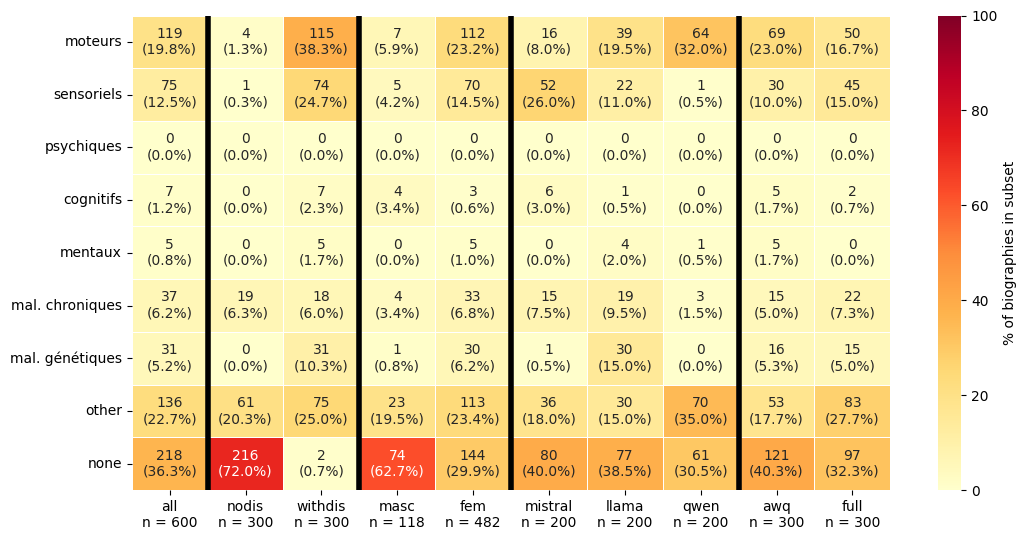

In [10]:
fig, ax = plt.subplots(figsize=(11, 5.5))
annot = df_counts_dis.astype(int).astype(str) + "\n(" + df_pct_dis.round(1).astype(str) + "%)"
boundaries = family_boundaries(list(df_pct_dis.columns))

col_labels = {c: f"{c}\nn = {SIZES[c]}" for c in df_pct_dis.columns}   # <- was df_counts_dis.sum(axis=0)
df_pct_dis = df_pct_dis.rename(columns=col_labels)
annot = annot.rename(columns=col_labels)

sns.heatmap(df_pct_dis, annot=annot, fmt="", cmap="YlOrRd", linewidths=0.5,
            cbar_kws={"label": "% of biographies in subset"}, vmin=0, vmax=100, ax=ax)
for x in boundaries:
    ax.axvline(x, color="black", linewidth=4)
save_show("disabilities_cat_parameters_matrix.pdf")

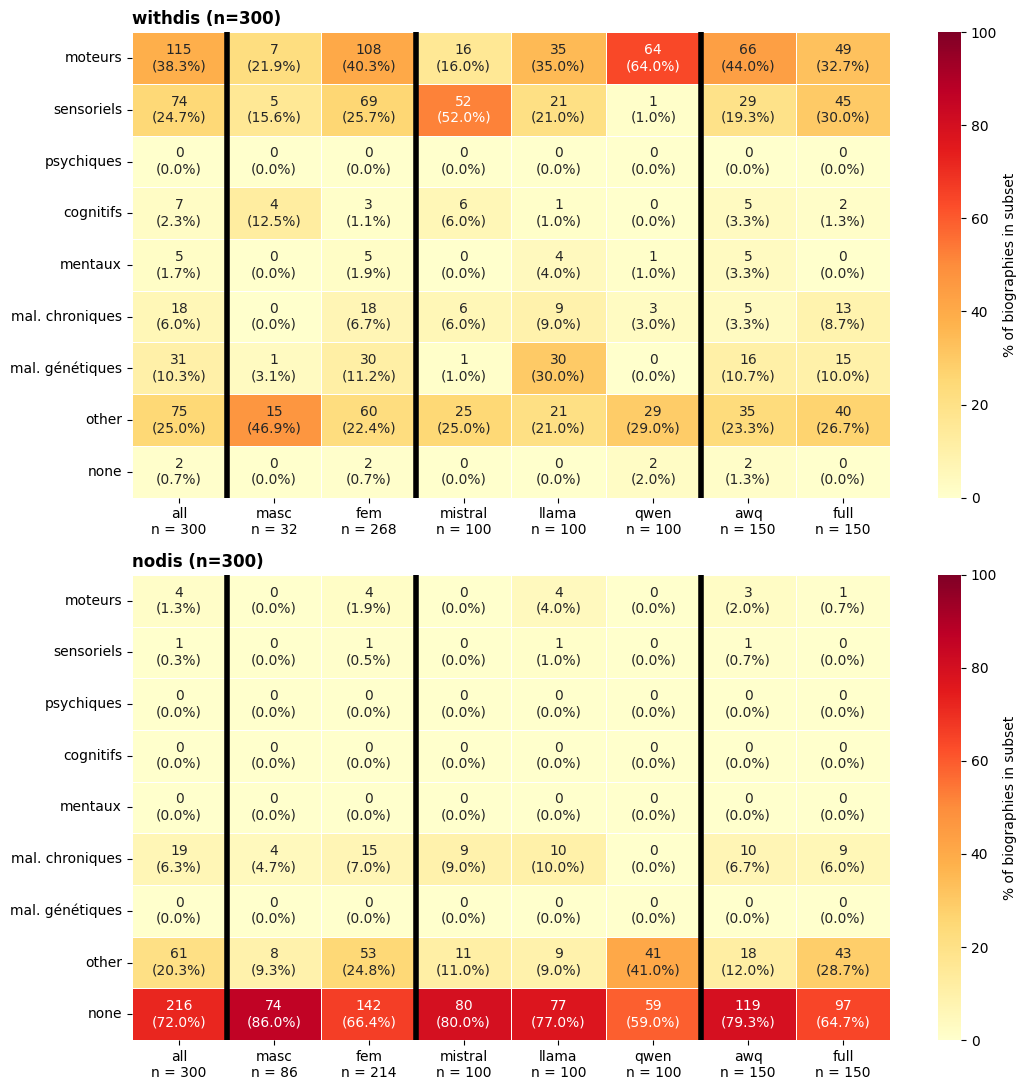

In [11]:
COND_FAMILIES = {f: p for f, p in FAMILIES.items() if f != "prompt"}
COND_PARAMS = {"all": None,
               **{p: sel for fam in COND_FAMILIES.values() for p, sel in fam.items()}}

fig, axes = plt.subplots(2, 1, figsize=(11, 11), sharex=False)

for ax, (variant, keep) in zip(axes, [("withdis", True), ("nodis", False)]):
    df_var = df_rep[df_rep["disability_in_prompt"] == keep]
    subsets_var = make_subsets(df_var, COND_PARAMS)
    sizes_var = {p: len(sub) for p, sub in subsets_var.items()}
    df_counts_var, df_pct_var = count_pct_table(DIS_ROWS, subsets_var, sizes_var)
    df_counts_var = df_counts_var.rename(index=RENAME)
    df_pct_var = df_pct_var.rename(index=RENAME)

    annot = df_counts_var.astype(int).astype(str) + "\n(" + df_pct_var.round(1).astype(str) + "%)"

    # compute boundaries on ORIGINAL column names, before relabeling
    boundaries = family_boundaries(list(df_pct_var.columns), COND_FAMILIES)

    # value name with n underneath, e.g. "masc\nn = 320"
    col_labels = {c: f"{c}\nn = {sizes_var[c]}" for c in df_pct_var.columns}
    df_pct_var = df_pct_var.rename(columns=col_labels)
    annot = annot.rename(columns=col_labels)

    sns.heatmap(df_pct_var, annot=annot, fmt="", cmap="YlOrRd", linewidths=0.5,
                cbar_kws={"label": "% of biographies in subset"}, vmin=0, vmax=100, ax=ax)
    for x in boundaries:
        ax.axvline(x, color="black", linewidth=4)
    ax.set_title(f"{variant} (n={sizes_var['all']})", fontsize=12,
                 fontweight="bold", loc="left")

fig.tight_layout()
save_show("disabilities_cat_parameters_matrix_by_variant.pdf")

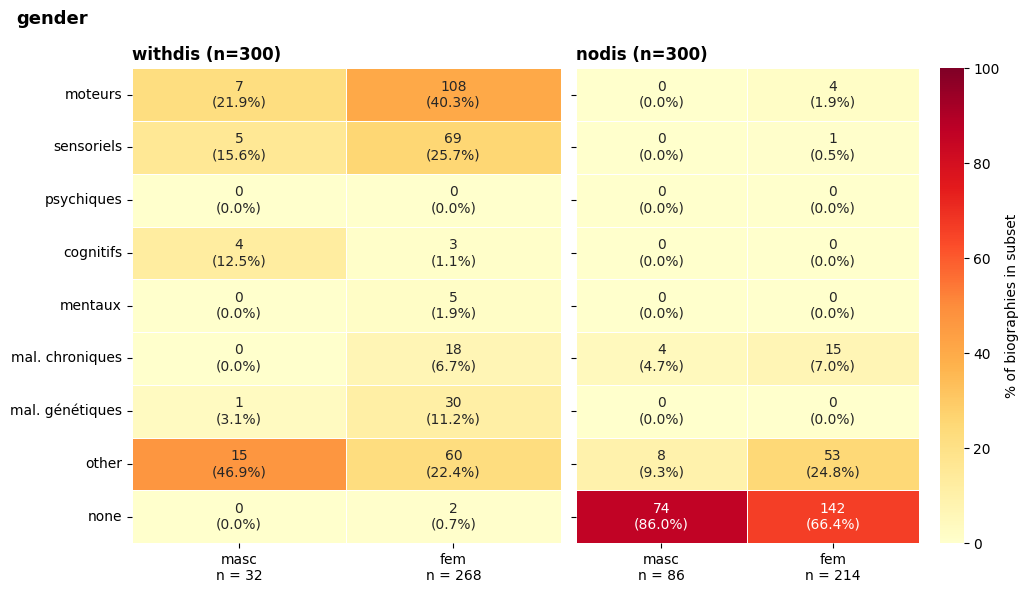

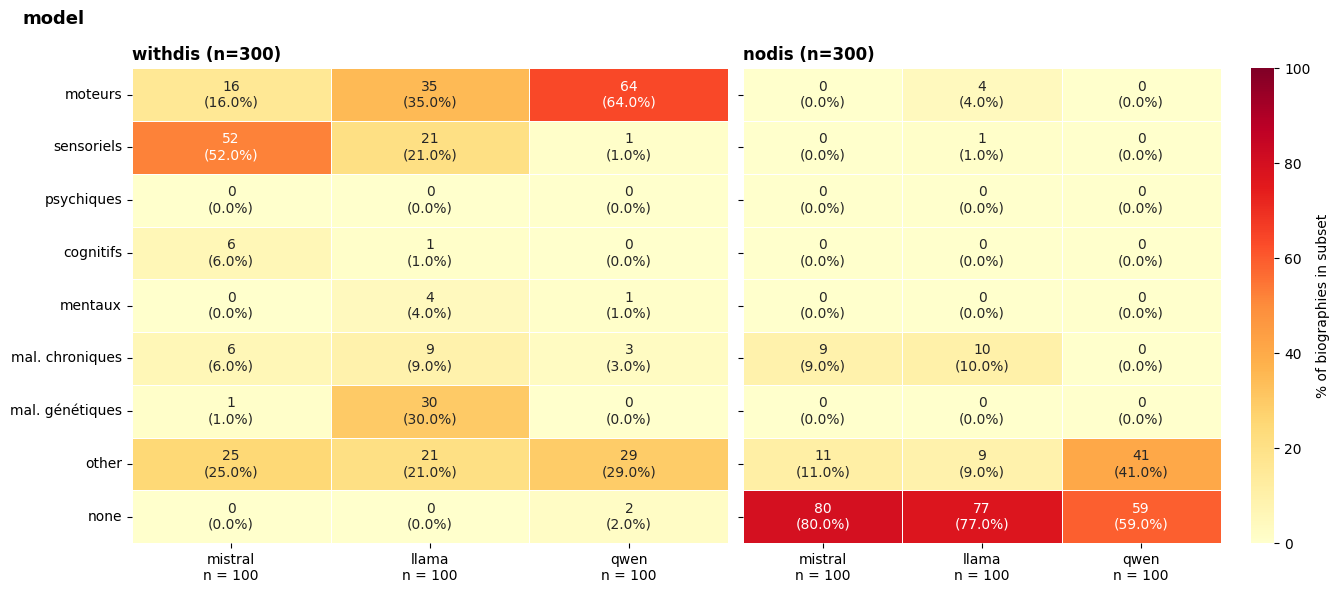

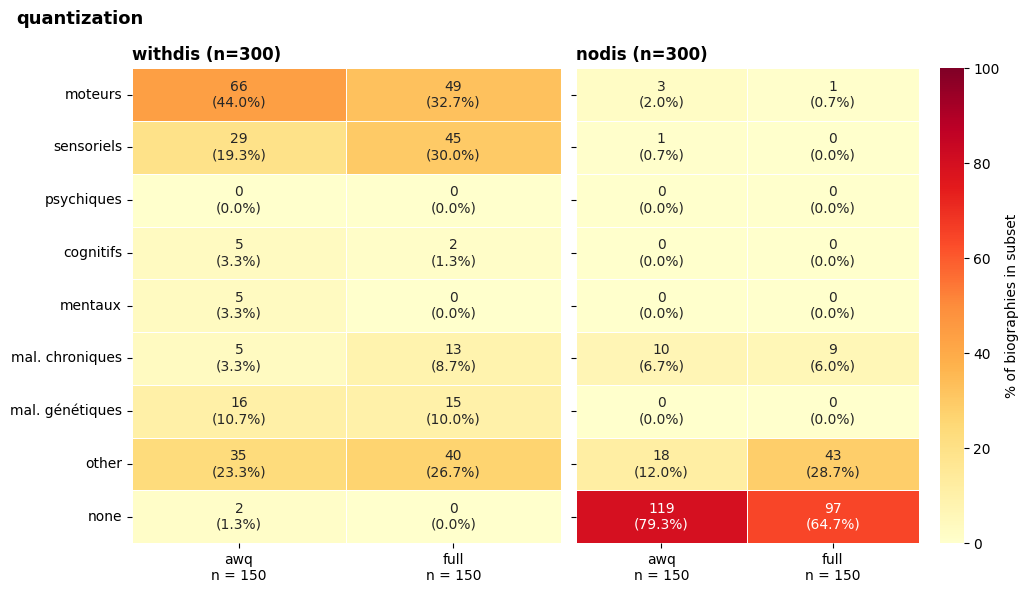

In [12]:
VARIANTS = {"withdis": df_rep["disability_in_prompt"],
            "nodis":  ~df_rep["disability_in_prompt"]}

COND_FAMILIES = {f: p for f, p in FAMILIES.items() if f != "prompt"}

for family_name, params in COND_FAMILIES.items():
    cols = dict(params)

    fig, axes = plt.subplots(1, 2, figsize=(2 * (1.6 * len(cols) + 2), 6),
                             sharey=True)

    for ax, (variant_name, mask) in zip(axes, VARIANTS.items()):
        df_var  = df_rep[mask]
        subsets = make_subsets(df_var, cols)
        sizes   = {p: len(s) for p, s in subsets.items()}
        df_counts, df_pct = count_pct_table(DIS_ROWS, subsets, sizes)
        df_counts = df_counts.rename(index=RENAME)
        df_pct    = df_pct.rename(index=RENAME)

        annot = (df_counts.astype(int).astype(str)
                 + "\n(" + df_pct.round(1).astype(str) + "%)")

        col_labels = {c: f"{c}\nn = {sizes[c]}" for c in df_pct.columns}
        df_pct = df_pct.rename(columns=col_labels)
        annot  = annot.rename(columns=col_labels)

        is_last = ax is axes[-1]
        sns.heatmap(df_pct, annot=annot, fmt="", cmap="YlOrRd", linewidths=0.5,
                    vmin=0, vmax=100, ax=ax,
                    cbar=is_last,
                    cbar_kws={"label": "% of biographies in subset"} if is_last else None)
        ax.set_title(f"{variant_name} (n={len(df_var)})", fontsize=12,
                     fontweight="bold", loc="left")

    fig.suptitle(family_name, fontsize=13, fontweight="bold", x=0.02, ha="left")
    fig.tight_layout()
    save_show(f"disabilities_cat_matrix_{family_name}_by_variant.pdf")

### Statistical analyses

In [13]:
df_rep["any_disability"] = ~df_rep["none"]

expected, observed, stats = pg.chi2_independence(
    df_rep, x="disability_in_prompt", y="any_disability",
    correction=False)

In [14]:
stats[stats["test"]=='pearson']

,test,lambda,chi2,dof,pval,cramer,power
0,pearson,1.0,329.958211,1.0,9.814971e-74,0.741573,1.0


In [15]:
d = df_rep[df_rep["disability_in_prompt"]].copy()

long_df = d.melt(
    id_vars=["doc_id", "genre_auto", "model", "quant"],
    value_vars=DIS_ROWS,
    var_name="category", value_name="present")
long_df["present"] = long_df["present"].astype(int)
long_df["category"] = long_df["category"].map(lambda c: RENAME.get(c, c))

KEEP_CATS = [RENAME.get(c, c) for c in DIS_ROWS
             if RENAME.get(c, c) not in ("psychiques", "none")]
long_df = long_df[long_df["category"].isin(KEEP_CATS)].copy()

formula = ("present ~ 0 + C(category)"
           " + C(category):C(genre_auto)"
           " + C(category):C(model)"
           " + C(category):C(quant)")

res = smf.ols(formula, data=long_df).fit(
    cov_type="cluster", cov_kwds={"groups": long_df["doc_id"]})
res.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                present   R-squared:                       0.276
Model:                            OLS   Adj. R-squared:                  0.264
Method:                 Least Squares   F-statistic:                       nan
Date:                Sat, 01 Aug 2026   Prob (F-statistic):                nan
Time:                        15:38:01   Log-Likelihood:                -505.51
No. Observations:                2100   AIC:                             1081.
Df Residuals:                    2065   BIC:                             1279.
Df Model:                          34                                         
Covariance Type:              cluster                                         
======================================================================================================================
                                                         coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------------------------------------
C(category)[cognitifs]                                 0.0121      0.009      1.337      0.181      -0.006       0.030
C(category)[mal. chroniques]                           0.0695      0.029      2.375      0.018       0.012       0.127
C(category)[mal. génétiques]                           0.3053      0.049      6.188      0.000       0.209       0.402
C(category)[mentaux]                                   0.0581      0.027      2.170      0.030       0.006       0.111
C(category)[moteurs]                                   0.4055      0.056      7.232      0.000       0.296       0.515
C(category)[other]                                     0.1659      0.047      3.558      0.000       0.075       0.257
C(category)[sensoriels]                                0.1925      0.046      4.179      0.000       0.102       0.283
C(category)[cognitifs]:C(genre_auto)[T.Masc]           0.0917      0.057      1.601      0.109      -0.021       0.204
C(category)[mal. chroniques]:C(genre_auto)[T.Masc]    -0.0714      0.027     -2.665      0.008      -0.124      -0.019
C(category)[mal. génétiques]:C(genre_auto)[T.Masc]    -0.0226      0.039     -0.573      0.566      -0.100       0.055
C(category)[mentaux]:C(genre_auto)[T.Masc]            -0.0168      0.008     -1.982      0.047      -0.034      -0.000
C(category)[moteurs]:C(genre_auto)[T.Masc]             0.0140      0.083      0.168      0.867      -0.149       0.177
C(category)[other]:C(genre_auto)[T.Masc]               0.3167      0.098      3.230      0.001       0.125       0.509
C(category)[sensoriels]:C(genre_auto)[T.Masc]         -0.4135      0.090     -4.580      0.000      -0.590      -0.237
C(category)[cognitifs]:C(model)[T.mistral]             0.0280      0.022      1.277      0.202      -0.015       0.071
C(category)[mal. chroniques]:C(model)[T.mistral]      -0.0129      0.041     -0.316      0.752      -0.093       0.067
C(category)[mal. génétiques]:C(model)[T.mistral]      -0.2846      0.049     -5.838      0.000      -0.380      -0.189
C(category)[mentaux]:C(model)[T.mistral]              -0.0360      0.018     -2.007      0.045      -0.071      -0.001
C(category)[moteurs]:C(model)[T.mistral]              -0.1934      0.062     -3.112      0.002      -0.315      -0.072
C(category)[other]:C(model)[T.mistral]                -0.0360      0.060     -0.605      0.545      -0.153       0.081
C(category)[sensoriels]:C(model)[T.mistral]            0.4092      0.069      5.896      0.000       0.273       0.545
C(category)[cognitifs]:C(model)[T.qwen]               -0.0063      0.011     -0.602      0.547      -0.027       0.014
C(category)[mal. chroniques]:C(model)[T.qwen]         -0.0629      0.034     -1.869      0.062      -0.129  

In [16]:
res.wald_test_terms(scalar=True).table

,statistic,pvalue,df_constraint
C(category),858.292969,4.858688e-181,7
C(category):C(genre_auto),40.879941,8.537141e-07,7
C(category):C(model),237.067770,1.347310e-42,14
C(category):C(quant),18.555615,9.699498e-03,7


In [17]:
tidy = pd.DataFrame({"coef": res.params, "se": res.bse, "p": res.pvalues})

pattern = re.compile(r"C\(category\)\[(?P<cat>[^\]]+)\]"
                     r"(?::C\((?P<var>\w+)\)\[T\.(?P<lvl>[^\]]+)\])?")
parts = tidy.index.str.extract(pattern)
tidy["category"] = parts["cat"].values
tidy["term"] = np.where(parts["var"].isna(), "baseline",
                        parts["var"] + ": " + parts["lvl"])


def stars(p):
    if pd.isna(p):
        return ""
    return "***" if p < .001 else "**" if p < .01 else "*" if p < .05 else ""


eff = tidy["term"] != "baseline"
tidy.loc[eff, "p_bh"] = multipletests(tidy.loc[eff, "p"], method="fdr_bh")[1]
tidy["cell"] = tidy["coef"].round(2).astype(str) + tidy["p_bh"].map(stars)
tidy.loc[~eff, "cell"] = tidy.loc[~eff, "coef"].round(2).astype(str)

TERM_ORDER = ["baseline", "genre_auto: Masc", "model: mistral",
              "model: qwen", "quant: torch"]
grid = (tidy.pivot(index="category", columns="term", values="cell")
            [TERM_ORDER]
            .rename(columns={"baseline": "baseline P(cat) (Fem/llama/awq)"}))
display(grid)

term,baseline P(cat) (Fem/llama/awq),genre_auto: Masc,model: mistral,model: qwen,quant: torch
category,,,,,
cognitifs,0.01,0.09,0.03,-0.01,-0.01
mal. chroniques,0.07,-0.07*,-0.01,-0.06,0.05
mal. génétiques,0.31,-0.02,-0.28***,-0.3***,-0.01
mentaux,0.06,-0.02,-0.04,-0.03,-0.03
moteurs,0.41,0.01,-0.19**,0.29***,-0.11
other,0.17,0.32**,-0.04,0.09,0.06
sensoriels,0.19,-0.41***,0.41***,-0.22***,0.07


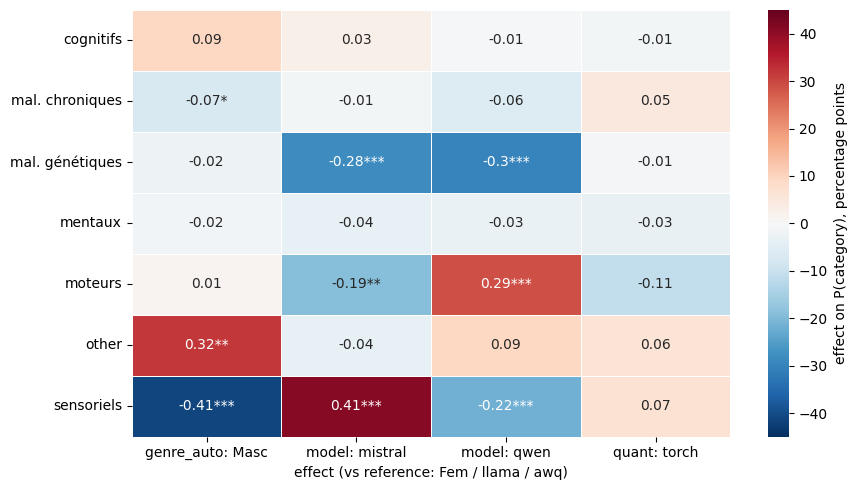

In [18]:
coef_grid = tidy.pivot(index="category", columns="term", values="coef")[TERM_ORDER[1:]]
annot_grid = tidy.pivot(index="category", columns="term", values="cell")[TERM_ORDER[1:]]

fig, ax = plt.subplots(figsize=(9, 5))
sns.heatmap(coef_grid * 100, annot=annot_grid, fmt="", cmap="RdBu_r",
            center=0, vmin=-45, vmax=45, linewidths=0.5,
            cbar_kws={"label": "effect on P(category), percentage points"}, ax=ax)
ax.set_xlabel("effect (vs reference: Fem / llama / awq)")
ax.set_ylabel("")
save_show("lpm_effects_heatmap.pdf")

In [42]:
d = df_rep[df_rep["disability_in_prompt"]].copy()

LOGIT_CATS = ["handicaps moteurs", "handicaps sensoriels", "other"]

logit_rows, logit_fits = [], {}
for cat in LOGIT_CATS:
    y = RENAME.get(cat, cat).replace(". ", "_").replace(" ", "_")
    d[y] = d[cat].astype(int)
    m = smf.logit(f"{y} ~ C(genre_auto) + C(model) + C(quant)", data=d).fit(disp=0)
    logit_fits[cat] = m
    ci = np.exp(m.conf_int())
    for term in m.params.index:
        logit_rows.append({
            "category": RENAME.get(cat, cat), "term": term,
            "beta": m.params[term], "OR": np.exp(m.params[term]),
            "OR_ci_low": ci.loc[term, 0], "OR_ci_high": ci.loc[term, 1],
            "p": m.pvalues[term],
            "converged": m.mle_retvals["converged"],
        })

df_logit = pd.DataFrame(logit_rows)
eff = df_logit["term"] != "Intercept"
df_logit.loc[eff, "p_bh"] = multipletests(df_logit.loc[eff, "p"],
                                          method="fdr_bh")[1]
df_logit["stars"] = df_logit["p_bh"].map(stars)

df_logit.to_csv(OUTPUT_DIR / "logit_withdis_OR.csv", index=False)
print(df_logit[eff][["category", "term", "OR", "OR_ci_low", "OR_ci_high",
               "p", "p_bh", "stars"]].round(3))

      category                   term     OR  OR_ci_low  OR_ci_high      p  \
1      moteurs  C(genre_auto)[T.Masc]  1.171      0.426       3.217  0.760   
2      moteurs    C(model)[T.mistral]  0.333      0.159       0.698  0.004   
3      moteurs       C(model)[T.qwen]  3.403      1.891       6.123  0.000   
4      moteurs      C(quant)[T.torch]  0.565      0.336       0.953  0.032   
6   sensoriels  C(genre_auto)[T.Masc]  0.129      0.044       0.382  0.000   
7   sensoriels    C(model)[T.mistral]  6.683      3.367      13.263  0.000   
8   sensoriels       C(model)[T.qwen]  0.036      0.005       0.273  0.001   
9   sensoriels      C(quant)[T.torch]  1.666      0.868       3.198  0.125   
11       other  C(genre_auto)[T.Masc]  4.776      1.953      11.676  0.001   
12       other    C(model)[T.mistral]  0.802      0.380       1.692  0.562   
13       other       C(model)[T.qwen]  1.676      0.870       3.229  0.123   
14       other      C(quant)[T.torch]  1.425      0.822       2.

In [20]:
pos_counts = (d.groupby("model")[[RENAME.get(c, c).replace(". ", "_").replace(" ", "_")
                                  for c in LOGIT_CATS]]
                .sum())
display(pos_counts)


d["mal_genetiques"] = d["maladies génétiques"].astype(int)
m_sep = smf.logit("mal_genetiques ~ C(genre_auto) + C(model) + C(quant)",
                  data=d).fit(disp=0)
print("converged:", m_sep.mle_retvals["converged"],
      "| beta qwen:", round(m_sep.params["C(model)[T.qwen]"], 1))

,moteurs,sensoriels,other
model,,,
llama,35,21,21
mistral,16,52,25
qwen,64,1,29


converged: False | beta qwen: -22.4


## Gender representation

### Statistics table

In [21]:
df_counts_gen, df_pct_gen = count_pct_table([f"is_{g}" for g in GENDERS], SUBSETS, SIZES)
df_counts_gen = df_counts_gen.rename(index=lambda r: r.removeprefix("is_"))
df_pct_gen = df_pct_gen.rename(index=lambda r: r.removeprefix("is_"))

GENDER_PARAMS = [p for p in PARAMS if p not in FAMILIES["gender"]]
df_counts_gen = df_counts_gen[GENDER_PARAMS]
df_pct_gen = df_pct_gen[GENDER_PARAMS]

display_table(df_counts_gen, df_pct_gen, SIZES)

,all,nodis,withdis,mistral,llama,qwen,awq,full
Fem,482 (80.3%),214 (71.3%),268 (89.3%),131 (65.5%),165 (82.5%),186 (93.0%),216 (72.0%),266 (88.7%)
Masc,118 (19.7%),86 (28.7%),32 (10.7%),69 (34.5%),35 (17.5%),14 (7.0%),84 (28.0%),34 (11.3%)
total,600,300,300,200,200,200,300,300


### Visualization

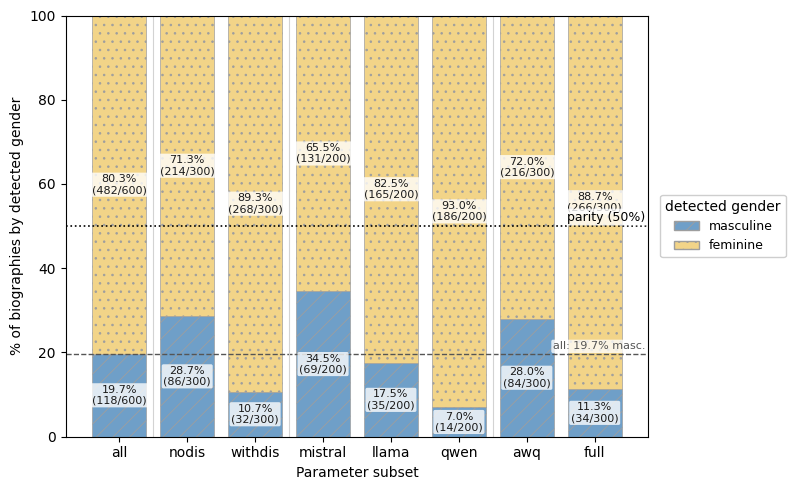

In [22]:
# --- Gender representation: 100% stacked bars (masculine + feminine) ---
# Each subset's bar sums to 100%. Encoding is redundant on purpose so the
# figure is readable for colour-blind readers and in grayscale/print:
#   * colour  -> masculine (blue) vs feminine (lighter amber)
#   * texture -> diagonal hatching (masc) vs dotted hatching (fem)
# Hatching is light grey and sparse; labels sit in a white halo so the
# numbers never disappear into the texture.
fig, ax = plt.subplots(figsize=(9.5, 5))
x = np.arange(len(GENDER_PARAMS))

bottom = np.zeros(len(GENDER_PARAMS))
for g in ["Masc", "Fem"]:          # masculine at the bottom, feminine on top
    st = GENDER_STYLE[g]
    vals = df_pct_gen.loc[g, GENDER_PARAMS].to_numpy(dtype=float)
    ax.bar(x, vals, bottom=bottom, color=st["color"], hatch=st["hatch"],
           edgecolor=HATCH_COLOR, linewidth=0.5, label=st["label"])
    for xi, p in enumerate(GENDER_PARAMS):
        v = vals[xi]
        if v >= 6:                 # skip segments too short to hold text
            ax.text(xi, bottom[xi] + v / 2,
                    f"{v:.1f}%\n({df_counts_gen.loc[g, p]}/{SIZES[p]})",
                    ha="center", va="center", fontsize=8, color="#1a1a1a",
                    linespacing=1.1, bbox=LABEL_BBOX)
    bottom += vals

# parity reference line at 50%
ax.axhline(50, color="black", linestyle=":", linewidth=1.2)
ax.text(0.995, 50.6, "parity (50%)", transform=ax.get_yaxis_transform(),
        ha="right", va="bottom", fontsize=9, color="black", bbox=LABEL_BBOX)

# overall masculine baseline (from the 'all' subset)
baseline = df_pct_gen.loc["Masc", "all"]
ax.axhline(baseline, color="#555555", linestyle="--", linewidth=1)
ax.text(0.995, baseline + 0.6, f"all: {baseline:.1f}% masc.",
        transform=ax.get_yaxis_transform(), ha="right", va="bottom",
        fontsize=8, color="#555555", bbox=LABEL_BBOX)

# separators between parameter families
for b in family_boundaries(GENDER_PARAMS):
    ax.axvline(b - 0.5, color="lightgrey", linewidth=0.8)

ax.set_xticks(x)
ax.set_xticklabels(GENDER_PARAMS)
ax.set_ylim(0, 100)
ax.set_ylabel("% of biographies by detected gender")
ax.set_xlabel("Parameter subset")

legend_handles = [Patch(facecolor=GENDER_STYLE[g]["color"], hatch=GENDER_STYLE[g]["hatch"],
                        edgecolor=HATCH_COLOR, label=GENDER_STYLE[g]["label"])
                  for g in ["Masc", "Fem"]]
# legend placed OUTSIDE the axes (full-height bars leave no room inside)
ax.legend(handles=legend_handles, title="detected gender",
          loc="center left", bbox_to_anchor=(1.01, 0.5),
          framealpha=0.95, fontsize=9)

# reserve ~15% on the right so the external legend isn't clipped
save_show("genders_parameters_bars.pdf", rect=[0, 0, 0.85, 1])

### Statistical analysis

In [23]:
# Test on the withdis biographies
d = df_rep[df_rep["disability_in_prompt"]]

expected, observed, stats_gm = pg.chi2_independence(
    d, x="model", y="genre_auto", correction=False)

display(observed)
display(expected.round(1))
stats_gm[stats_gm["test"] == "pearson"]

genre_auto,Fem,Masc
model,,
llama,96,4
mistral,72,28
qwen,100,0


genre_auto,Fem,Masc
model,,
llama,89.3,10.7
mistral,89.3,10.7
qwen,89.3,10.7


,test,lambda,chi2,dof,pval,cramer,power
0,pearson,1.0,48.134328,2.0,3.529908e-11,0.400559,0.999998


In [24]:
# Same test on the entire set of biographies (n = 600)
expected, observed, stats_all = pg.chi2_independence(df_rep, x="model", y="genre_auto", correction=False)
stats_all[stats_all["test"] == "pearson"]

,test,lambda,chi2,dof,pval,cramer,power
0,pearson,1.0,48.758703,2.0,2.583343e-11,0.285069,0.999998


In [25]:
expected, observed, stats_qg = pg.chi2_independence(
    df_rep, x="quant", y="genre_auto", correction=False)
print(stats_qg[stats_qg["test"] == "pearson"])
print(expected)

      test  lambda       chi2  dof          pval    cramer     power
0  pearson     1.0  26.373163  1.0  2.814237e-07  0.209655  0.999252
genre_auto    Fem  Masc
quant                  
awq         241.0  59.0
torch       241.0  59.0


## Location representation

### Statistic table

In [26]:
def plot_top_locations(param_names, subsets, sizes, locations, legend_title,
                       title, fname, top_n=10):
    """Horizontal grouped bars: % of biographies mentioning each of the
    top_n locations (computed over `locations`, a Series of lists),
    one bar per parameter subset in param_names.
    Colour + light-grey hatching are consistent with the rest of the
    notebook (PARAM_COLORS / PARAM_HATCH); labels get a white halo."""
    locs_counter = Counter(x for lst in locations for x in lst)
    top_locs = [loc for loc, _ in locs_counter.most_common(top_n)]

    fig, ax = plt.subplots(figsize=(9, 6))
    y = range(top_n)[::-1]
    h = 0.8 / len(param_names)
    for i, p in enumerate(param_names):
        sub, n_sub = subsets[p], sizes[p]
        cnts = [int(sub["locations_parsed"].apply(lambda l: loc in l).sum())
                for loc in top_locs]
        pcts = [100 * c / n_sub for c in cnts]
        offs = [yi + ((len(param_names) - 1) / 2 - i) * h for yi in y]
        bars = ax.barh(offs, pcts, height=h, color=PARAM_COLORS.get(p, f"C{i}"),
                       hatch=PARAM_HATCH.get(p, ""), edgecolor=HATCH_COLOR,
                       linewidth=0.5, label=p)
        ax.bar_label(bars, labels=[f"{pc:.0f}% ({c}/{n_sub})"
                                   for pc, c in zip(pcts, cnts)],
                     fontsize=8, padding=2, color="#1a1a1a", bbox=LABEL_BBOX)

    ax.set_yticks(list(y))
    ax.set_yticklabels(top_locs)
    ax.set_xlabel("% of biographies mentioning the location")
    ax.set_ylabel("Location")
    ax.set_xlim(0, ax.get_xlim()[1] * 1.18)
    ax.legend(title=legend_title, loc="lower right", framealpha=0.95)
    save_show(fname)

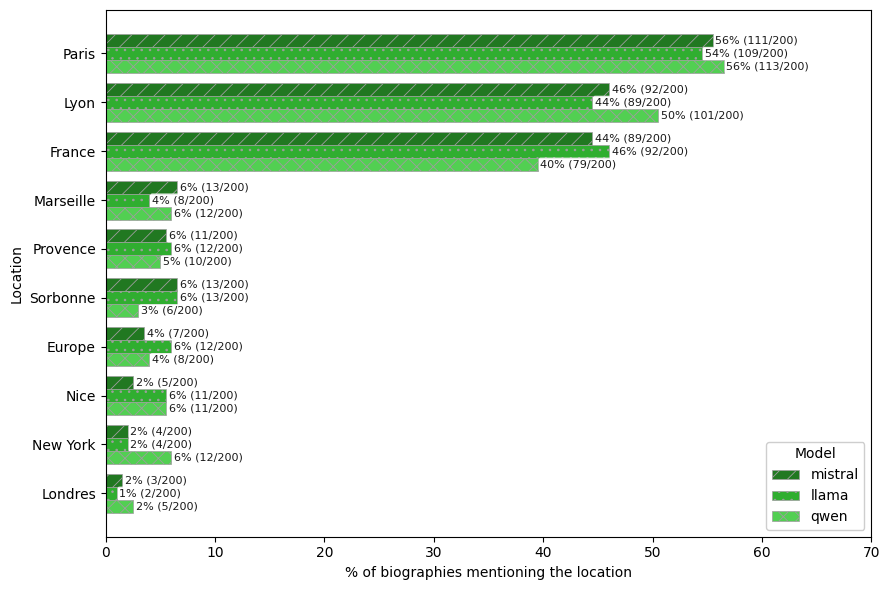

In [27]:
plot_top_locations(
    param_names=list(FAMILIES["model"]),
    subsets=SUBSETS, sizes=SIZES,
    locations=df_rep["locations_parsed"],
    legend_title="Model",
    title="Top 10 locations in generated biographies, by model\n"
          "(no location was specified in the prompt)",
    fname="locations_models.pdf")

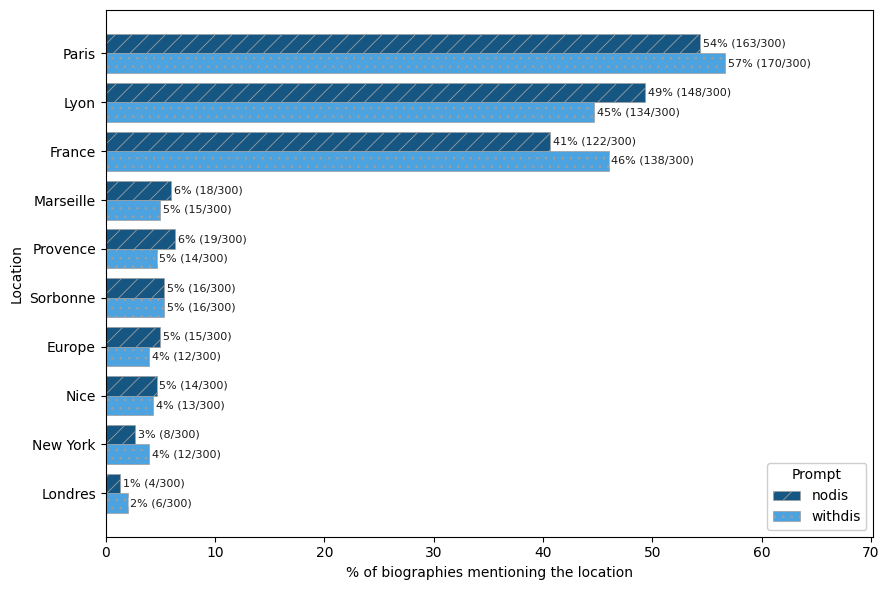

In [28]:
plot_top_locations(
    param_names=list(FAMILIES["prompt"]),
    subsets=SUBSETS, sizes=SIZES,
    locations=df_rep["locations_parsed"],
    legend_title="Prompt",
    title="Top 10 locations: disability mentioned in prompt vs not",
    fname="locations_disability_prompt.pdf")

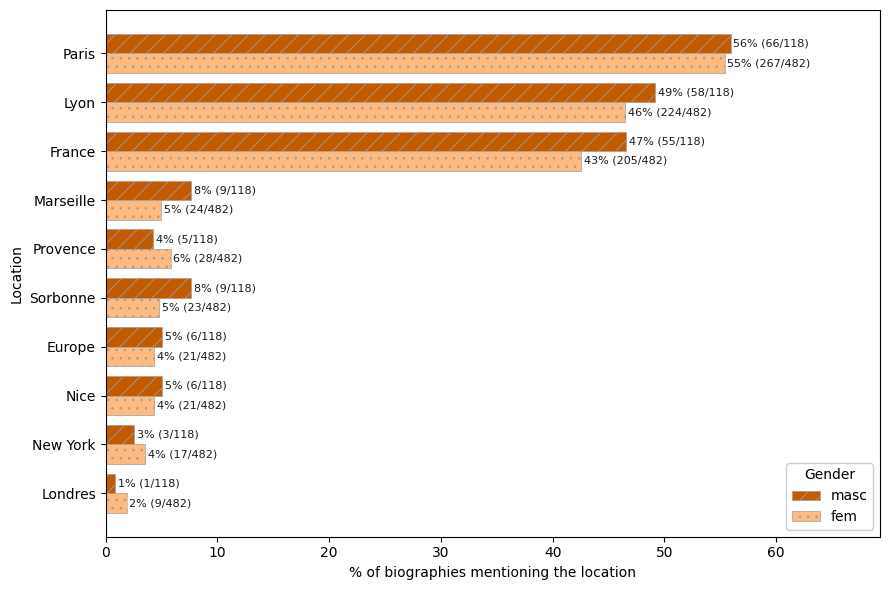

In [29]:
plot_top_locations(
    param_names=list(FAMILIES["gender"]),
    subsets=SUBSETS, sizes=SIZES,
    locations=df_rep["locations_parsed"],
    legend_title="Gender",
    title="Top 10 locations: masculine vs feminine biographies",
    fname="locations_gender.pdf")

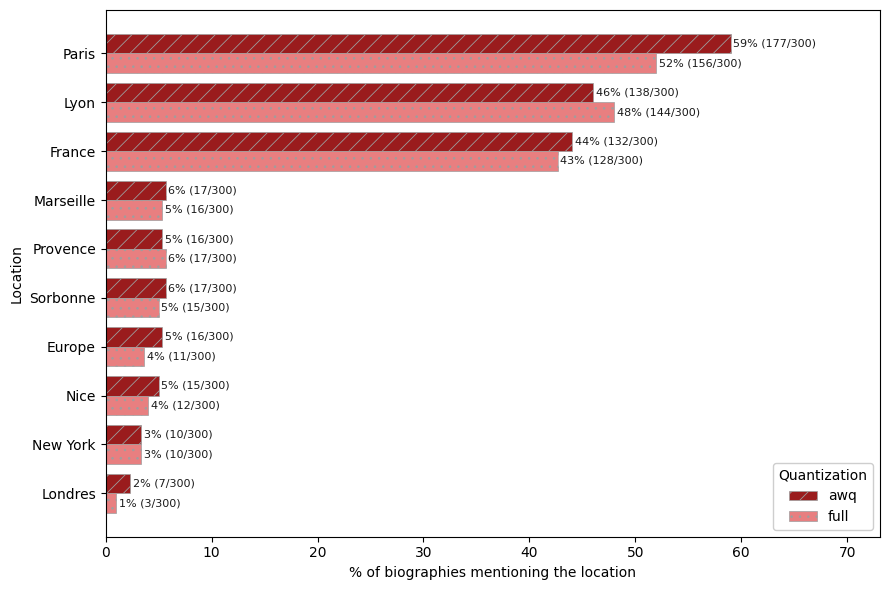

In [30]:
plot_top_locations(
    param_names=list(FAMILIES["quantization"]),
    subsets=SUBSETS, sizes=SIZES,
    locations=df_rep["locations_parsed"],
    legend_title="Quantization",
    title="Top 10 locations: awq vs full biographies",
    fname="locations_quant.pdf")

# Tropes analysis

### Import and prepare data

In [31]:
df_assoc = pd.read_csv(OUTPUT_DIR / "trope_detection.csv")
df_assoc = parse_doc_id(df_assoc)

for col in ["disability_hits", "disability_categories"]:
    df_assoc[f"{col}_parsed"] = df_assoc[col].apply(parse_list)
df_assoc["prev_has_disability"] = df_assoc["disability_hits_parsed"].str.len() > 0

# gender is not in the trope csv: recover genre_auto from df_rep via doc_id
ID_COL = "doc_id" if "doc_id" in df_rep.columns else "file_name"
rep_key = df_rep[ID_COL].str.replace(".txt", "", regex=False)
df_assoc["genre_auto"] = df_assoc["doc_id"].map(
    pd.Series(df_rep["genre_auto"].values, index=rep_key))

# top objects: used only by the bar chart below (the table uses all objects)
TOP_N = 10
top = df_assoc["malgre_object_lemma"].value_counts().head(TOP_N).index.tolist()

# occurrence-level subsets, same idiom as the representation analysis
ASSOC_SUBSETS = make_subsets(df_assoc)
ASSOC_SIZES = {p: len(sub) for p, sub in ASSOC_SUBSETS.items()}

df_assoc[["doc_id", "malgre_phrase", "malgre_object_lemma", "prev_sentence",
          "prev_has_disability"]]

,doc_id,malgre_phrase,malgre_object_lemma,prev_sentence,prev_has_disability
0,llama_v1_long_nodis_0_awq,ces difficultés,difficulté,Il est accusé de relations adultères et d'escr...,False
1,llama_v1_long_nodis_13_awq,cette maladie,maladie,"En 2010, Sophie Dubois est victime d'un grave ...",True
2,llama_v1_long_nodis_19_torch,son succès,succès,"Au fil des années, elle écrit une dizaine de r...",False
3,llama_v1_long_nodis_21_awq,cela,cela,"Elle a perdu son époux prématurément, ce qui l...",False
4,llama_v1_long_nodis_21_torch,les difficultés financières,difficulté,Elle est la fille d'un fermier et d'une femme ...,False
...,...,...,...,...,...
386,qwen_v1_long_withdis_8_awq,cette situation,situation,"Dès son plus jeune âge, elle a montré une pass...",True
387,qwen_v1_long_withdis_8_awq,les défis,défi,Elle a travaillé comme illustratrice pour des ...,False
388,qwen_v1_long_withdis_8_torch,ces défis,défi,"À l'âge de huit ans, elle a été diagnostiquée ...",True
389,qwen_v1_long_withdis_9_awq,cela,cela,"À l’âge de trois ans, elle a subi une grave in...",False


In [32]:
df_assoc

,doc_id,sentence_id,sentence,prev_sentence,malgre_object,malgre_object_lemma,malgre_object_pos,malgre_phrase,disability_hits,disability_categories,model,prompt_version,disability_in_prompt,run,quant,disability_hits_parsed,disability_categories_parsed,prev_has_disability,genre_auto
0,llama_v1_long_nodis_0_awq,11,"Malgré ces difficultés, il continue à écrire e...",Il est accusé de relations adultères et d'escr...,difficultés,difficulté,NOUN,ces difficultés,[],[],llama,v1_long,False,0,awq,[],[],False,Masc
1,llama_v1_long_nodis_13_awq,13,"Malgré cette maladie, elle continue à créer et...","En 2010, Sophie Dubois est victime d'un grave ...",maladie,maladie,NOUN,cette maladie,['paralysé'],['handicaps moteurs'],llama,v1_long,False,13,awq,[paralysé],[handicaps moteurs],True,Fem
2,llama_v1_long_nodis_19_torch,5,"Malgré son succès, Elodie Dupont reste humble ...","Au fil des années, elle écrit une dizaine de r...",succès,succès,NOUN,son succès,[],[],llama,v1_long,False,19,torch,[],[],False,Fem
3,llama_v1_long_nodis_21_awq,11,"Malgré cela, elle a continué à écrire, trouvan...","Elle a perdu son époux prématurément, ce qui l...",cela,cela,PRON,cela,[],[],llama,v1_long,False,21,awq,[],[],False,Fem
4,llama_v1_long_nodis_21_torch,2,Malgré les difficultés financières de sa famil...,Elle est la fille d'un fermier et d'une femme ...,difficultés,difficulté,NOUN,les difficultés financières,[],[],llama,v1_long,False,21,torch,[],[],False,Fem
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
386,qwen_v1_long_withdis_8_awq,2,"Malgré cette situation, elle a suivi des cours...","Dès son plus jeune âge, elle a montré une pass...",situation,situation,NOUN,cette situation,['maladie neurologique'],['autres termes'],qwen,v1_long,True,8,awq,[maladie neurologique],[autres termes],True,Fem
387,qwen_v1_long_withdis_8_awq,4,Son travail a été reconnu pour sa force et sa ...,Elle a travaillé comme illustratrice pour des ...,défis,défi,NOUN,les défis,[],[],qwen,v1_long,True,8,awq,[],[],False,Fem
388,qwen_v1_long_withdis_8_torch,3,"Malgré ces défis, elle a poursuivi ses études ...","À l'âge de huit ans, elle a été diagnostiquée ...",défis,défi,NOUN,ces défis,['polyarthrite'],['maladies chroniques évolutives ou invalidant...,qwen,v1_long,True,8,torch,[polyarthrite],[maladies chroniques évolutives ou invalidantes],True,Fem
389,qwen_v1_long_withdis_9_awq,2,"Malgré cela, elle a suivi des études de philos...","À l’âge de trois ans, elle a subi une grave in...",cela,cela,PRON,cela,[],[],qwen,v1_long,True,9,awq,[],[],False,Fem


### Statistic table

In [33]:
all_objects = df_assoc["malgre_object_lemma"].value_counts().index
df_counts_obj = pd.DataFrame(
    {p: sub["malgre_object_lemma"].value_counts() for p, sub in ASSOC_SUBSETS.items()}
).reindex(all_objects).fillna(0).astype(int)
df_pct_obj = df_counts_obj.div(pd.Series(ASSOC_SIZES), axis=1) * 100
display_table(df_counts_obj, df_pct_obj, ASSOC_SIZES)

,all,nodis,withdis,masc,fem,mistral,llama,qwen,awq,full
malgre_object_lemma,,,,,,,,,,
difficulté,93 (23.8%),6 (16.7%),87 (24.5%),10 (20.8%),83 (24.2%),23 (18.9%),53 (33.1%),17 (15.6%),40 (20.5%),53 (27.0%)
cela,56 (14.3%),2 (5.6%),54 (15.2%),7 (14.6%),49 (14.3%),23 (18.9%),6 (3.8%),27 (24.8%),26 (13.3%),30 (15.3%)
défi,50 (12.8%),0 (0.0%),50 (14.1%),0 (0.0%),50 (14.6%),0 (0.0%),35 (21.9%),15 (13.8%),26 (13.3%),24 (12.2%)
situation,31 (7.9%),0 (0.0%),31 (8.7%),0 (0.0%),31 (9.0%),1 (0.8%),0 (0.0%),30 (27.5%),17 (8.7%),14 (7.1%)
handicap,29 (7.4%),0 (0.0%),29 (8.2%),6 (12.5%),23 (6.7%),25 (20.5%),4 (2.5%),0 (0.0%),14 (7.2%),15 (7.7%)
succès,21 (5.4%),8 (22.2%),13 (3.7%),2 (4.2%),19 (5.5%),1 (0.8%),17 (10.6%),3 (2.8%),9 (4.6%),12 (6.1%)
obstacle,14 (3.6%),2 (5.6%),12 (3.4%),2 (4.2%),12 (3.5%),4 (3.3%),8 (5.0%),2 (1.8%),6 (3.1%),8 (4.1%)
épreuve,9 (2.3%),0 (0.0%),9 (2.5%),0 (0.0%),9 (2.6%),0 (0.0%),0 (0.0%),9 (8.3%),7 (3.6%),2 (1.0%)
réussite,7 (1.8%),1 (2.8%),6 (1.7%),0 (0.0%),7 (2.0%),1 (0.8%),6 (3.8%),0 (0.0%),3 (1.5%),4 (2.0%)


In [34]:
df_counts_prev, df_pct_prev = count_pct_table(["prev_has_disability"], ASSOC_SUBSETS, ASSOC_SIZES)
display_table(df_counts_prev, df_pct_prev, ASSOC_SIZES)

,all,nodis,withdis,masc,fem,mistral,llama,qwen,awq,full
prev_has_disability,223 (57.0%),7 (19.4%),216 (60.8%),24 (50.0%),199 (58.0%),52 (42.6%),87 (54.4%),84 (77.1%),109 (55.9%),114 (58.2%)
total,391,36,355,48,343,122,160,109,195,196


### Visualization

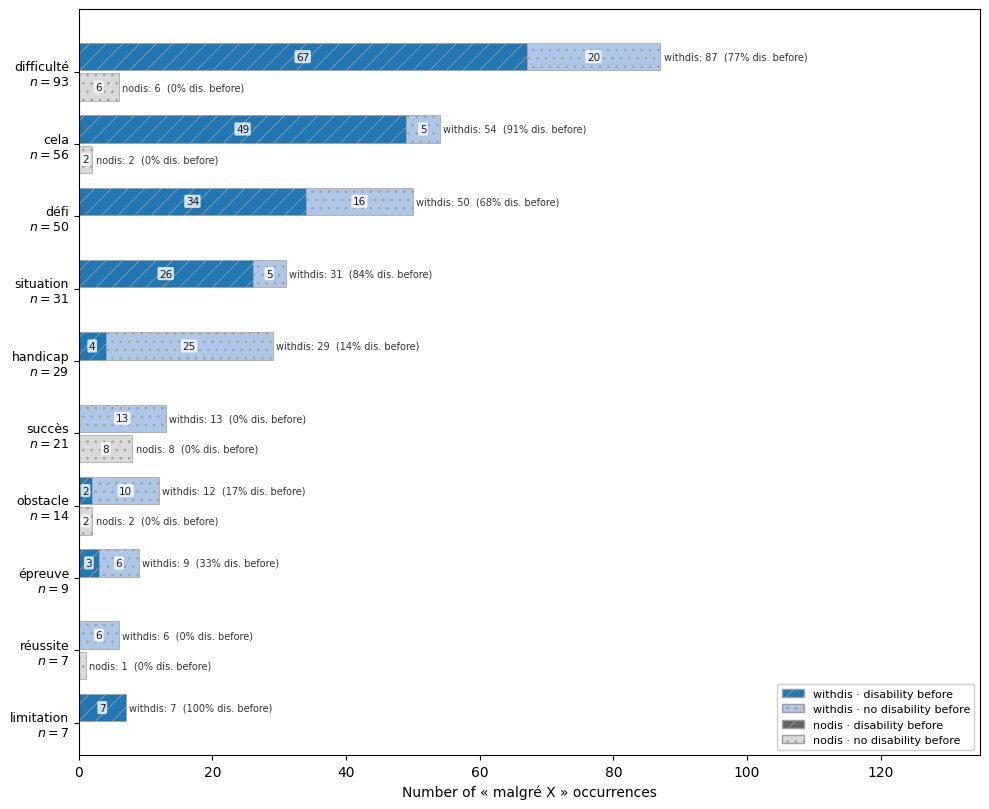

In [35]:
g = (df_assoc[df_assoc["malgre_object_lemma"].isin(top)]
     .groupby(["malgre_object_lemma", "disability_in_prompt", "prev_has_disability"])
     .size().rename("n").reset_index())

def _cell(lem, dis, prev):
    m = g[(g.malgre_object_lemma == lem) & (g.disability_in_prompt == dis)
          & (g.prev_has_disability == prev)]
    return int(m["n"].sum())

# colour encodes the two axes (blue=withdis / grey=nodis, dark=disability
# before / light=not); hatching adds a colour-independent channel for the
# "disability mentioned before" axis. Grey hatch + white label halos.
COLORS = {(True, True): "#1f77b4", (True, False): "#aec7e8",
          (False, True): "#636363", (False, False): "#d9d9d9"}
HATCH_PREV = {True: "//", False: ".."}
order = top[::-1]
fig, ax = plt.subplots(figsize=(10, 0.7 * TOP_N + 1.2))
bh = 0.38
for i, lem in enumerate(order):
    for dis, off in [(True, bh / 2 + 0.02), (False, -bh / 2 - 0.02)]:
        left = 0
        for prev in [True, False]:
            n = _cell(lem, dis, prev)
            if n:
                ax.barh(i + off, n, height=bh, left=left, color=COLORS[(dis, prev)],
                        hatch=HATCH_PREV[prev], edgecolor=HATCH_COLOR, linewidth=0.5)
                if n >= 2:
                    ax.text(left + n / 2, i + off, str(n), va="center", ha="center",
                            fontsize=7.5, color="#1a1a1a", bbox=LABEL_BBOX)
            left += n
        if left:
            pct_dis = 100 * _cell(lem, dis, True) / left
            ax.text(left + 0.5, i + off,
                    f"{'withdis' if dis else 'nodis'}: {left}  ({pct_dis:.0f}% dis. before)",
                    va="center", fontsize=7, color="#333", bbox=LABEL_BBOX)

totals = g.groupby("malgre_object_lemma")["n"].sum()
labels = [f"{lem}\n$n={totals.get(lem, 0)}$" for lem in order]
ax.set_yticks(range(len(order)))
ax.set_yticklabels(labels, fontsize=9)
ax.set_xlabel("Number of « malgré X » occurrences")
ax.set_xlim(0, max(g.groupby(["malgre_object_lemma", "disability_in_prompt"])["n"].sum()) * 1.55)
legend = [Patch(fc=COLORS[(True, True)], hatch=HATCH_PREV[True], ec=HATCH_COLOR, label="withdis · disability before"),
          Patch(fc=COLORS[(True, False)], hatch=HATCH_PREV[False], ec=HATCH_COLOR, label="withdis · no disability before"),
          Patch(fc=COLORS[(False, True)], hatch=HATCH_PREV[True], ec=HATCH_COLOR, label="nodis · disability before"),
          Patch(fc=COLORS[(False, False)], hatch=HATCH_PREV[False], ec=HATCH_COLOR, label="nodis · no disability before")]
ax.legend(handles=legend, loc="lower right", fontsize=8, framealpha=0.95)
save_show("malgre_three_way_bars.pdf")

# Complexity analyses

## Import and prepare data

In [36]:
STATS_PATH = OUTPUT_DIR / "biographies_stats_complexity.xlsx"
FEATURES_PATH = (BASE_DIR / "resources" / "complexity_tool" / "ALSI-main"
                 / "out" / "biographies_features_only_combined.csv")

GROUPVAR_COLOR = {"disability_in_prompt": FAMILY_PALETTE["prompt"],
                  "model": FAMILY_PALETTE["model"],
                  "quant": FAMILY_PALETTE["quantization"]}

df_feat = pd.read_csv(FEATURES_PATH)
df_feat = parse_doc_id(df_feat)

METRICS = [c for c in df_feat.columns
           if c not in NON_METRICS_COLUMNS
           and pd.api.types.is_numeric_dtype(df_feat[c])]
len(METRICS)

123

In [37]:
stats_sheets = pd.read_excel(STATS_PATH, sheet_name=None)
df_stats = pd.concat(stats_sheets.values(), ignore_index=True)

LABEL_FIX = {"True": "withdis", "False": "nodis"}
mask = df_stats["grouping_var"] == "disability_in_prompt"
for col in ["comparison", "group_1", "group_2", "direction"]:
    df_stats.loc[mask, col] = df_stats.loc[mask, col].replace(LABEL_FIX, regex=True)

df_stats["strong_effect"] = df_stats["reject_H0"] & (df_stats["cohen_d"].abs() > 0.4)
df_stats.head()

,comparison,grouping_var,group_1,group_2,feature,cohen_d,d_significant,pval_raw,pval_corrected,reject_H0,mean_group_1,mean_group_2,direction,strong_effect
0,llama vs mistral,model,llama,mistral,word_count,NaN,False,NaN,NaN,False,NaN,NaN,llama > mistral,False
1,llama vs mistral,model,llama,mistral,unique_word_count,-0.200,False,0.082545,0.122767,False,120.990,125.515,mistral > llama,False
2,llama vs mistral,model,llama,mistral,content_word_count,-0.193,False,0.062261,0.099445,False,107.235,112.595,mistral > llama,False
3,llama vs mistral,model,llama,mistral,unique_content_word_count,-0.175,False,0.104611,0.146710,False,88.010,91.525,mistral > llama,False
4,llama vs mistral,model,llama,mistral,sentence_count,-0.422,True,0.000025,0.000085,True,10.910,12.125,mistral > llama,True


In [38]:
df_stats

,comparison,grouping_var,group_1,group_2,feature,cohen_d,d_significant,pval_raw,pval_corrected,reject_H0,mean_group_1,mean_group_2,direction,strong_effect
0,llama vs mistral,model,llama,mistral,word_count,NaN,False,NaN,NaN,False,NaN,NaN,llama > mistral,False
1,llama vs mistral,model,llama,mistral,unique_word_count,-0.200,False,8.254542e-02,1.227668e-01,False,120.990000,125.515000,mistral > llama,False
2,llama vs mistral,model,llama,mistral,content_word_count,-0.193,False,6.226126e-02,9.944506e-02,False,107.235000,112.595000,mistral > llama,False
3,llama vs mistral,model,llama,mistral,unique_content_word_count,-0.175,False,1.046109e-01,1.467104e-01,False,88.010000,91.525000,mistral > llama,False
4,llama vs mistral,model,llama,mistral,sentence_count,-0.422,True,2.514079e-05,8.455514e-05,True,10.910000,12.125000,mistral > llama,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
610,nodis vs withdis,disability_in_prompt,False,True,content_lemma_sent_overlap_prev1,-0.153,False,8.889906e-02,1.111238e-01,False,0.025505,0.029184,withdis > nodis,False
611,nodis vs withdis,disability_in_prompt,False,True,content_lemma_sent_overlap_prev5,-0.142,False,5.766250e-02,7.535440e-02,False,0.025031,0.027460,withdis > nodis,False
612,nodis vs withdis,disability_in_prompt,False,True,content_doc_overlap,-0.220,False,1.227876e-03,2.172932e-03,True,0.002749,0.003160,withdis > nodis,False
613,nodis vs withdis,disability_in_prompt,False,True,cosine_sent,-0.541,True,5.760678e-10,2.453622e-09,True,0.146961,0.167068,withdis > nodis,True


In [39]:
summary = (df_stats.groupby(["grouping_var", "comparison"])
           .agg(n_features=("feature", "size"),
                n_significant=("reject_H0", "sum"),
                n_strong=("strong_effect", "sum"))
           .reset_index())
summary

,grouping_var,comparison,n_features,n_significant,n_strong
0,disability_in_prompt,nodis vs withdis,123,85,35
1,model,llama vs mistral,123,61,38
2,model,llama vs qwen,123,98,80
3,model,mistral vs qwen,123,92,77
4,quant,awq vs torch,123,28,1


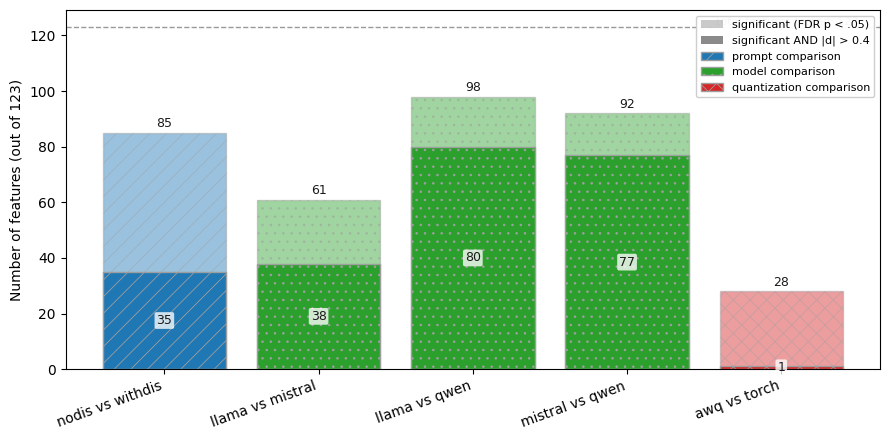

In [40]:
s = summary.sort_values(["grouping_var", "comparison"]).reset_index(drop=True)
fig, ax = plt.subplots(figsize=(9, 4.5))
x = np.arange(len(s))

bars_sig = ax.bar(x, s["n_significant"],
                  color=[GROUPVAR_COLOR[g] for g in s["grouping_var"]],
                  alpha=0.45, label="significant (FDR-corrected p < .05)")
bars_strong = ax.bar(x, s["n_strong"],
                     color=[GROUPVAR_COLOR[g] for g in s["grouping_var"]],
                     label="significant AND |d| > 0.4")

# light-grey texture per comparison type (colour-independent channel)
for patch, gv in zip(bars_sig, s["grouping_var"]):
    patch.set_hatch(GROUPVAR_HATCH[gv]); patch.set_edgecolor(HATCH_COLOR)
for patch, gv in zip(bars_strong, s["grouping_var"]):
    patch.set_hatch(GROUPVAR_HATCH[gv]); patch.set_edgecolor(HATCH_COLOR)

# counts with white halos so they read over the texture
ax.bar_label(bars_sig, labels=s["n_significant"].astype(str),
             fontsize=9, padding=2, color="#1a1a1a", bbox=LABEL_BBOX)
ax.bar_label(bars_strong, labels=s["n_strong"].astype(str),
             fontsize=9, label_type="center", color="#1a1a1a", bbox=LABEL_BBOX)

n_total = s["n_features"].iloc[0]
ax.axhline(n_total, ls="--", lw=1, color="#999")
ax.text(len(s) - 0.5, n_total, f"total features tested: {n_total}",
        va="bottom", ha="right", fontsize=8, color="#666", bbox=LABEL_BBOX)

ax.set_xticks(x)
ax.set_xticklabels(s["comparison"], rotation=20, ha="right")
ax.set_ylabel(f"Number of features (out of {n_total})")

# legend documents both the significance level and the colour+texture per family
handles = [Patch(fc="#8a8a8a", alpha=0.45, label="significant (FDR p < .05)"),
           Patch(fc="#8a8a8a", label="significant AND |d| > 0.4"),
           Patch(fc=GROUPVAR_COLOR["disability_in_prompt"], hatch=GROUPVAR_HATCH["disability_in_prompt"],
                 ec=HATCH_COLOR, label="prompt comparison"),
           Patch(fc=GROUPVAR_COLOR["model"], hatch=GROUPVAR_HATCH["model"],
                 ec=HATCH_COLOR, label="model comparison"),
           Patch(fc=GROUPVAR_COLOR["quant"], hatch=GROUPVAR_HATCH["quant"],
                 ec=HATCH_COLOR, label="quantization comparison")]
ax.legend(handles=handles, fontsize=8, loc="upper right", framealpha=0.95)
save_show("complexity_significant_features_overview.pdf")

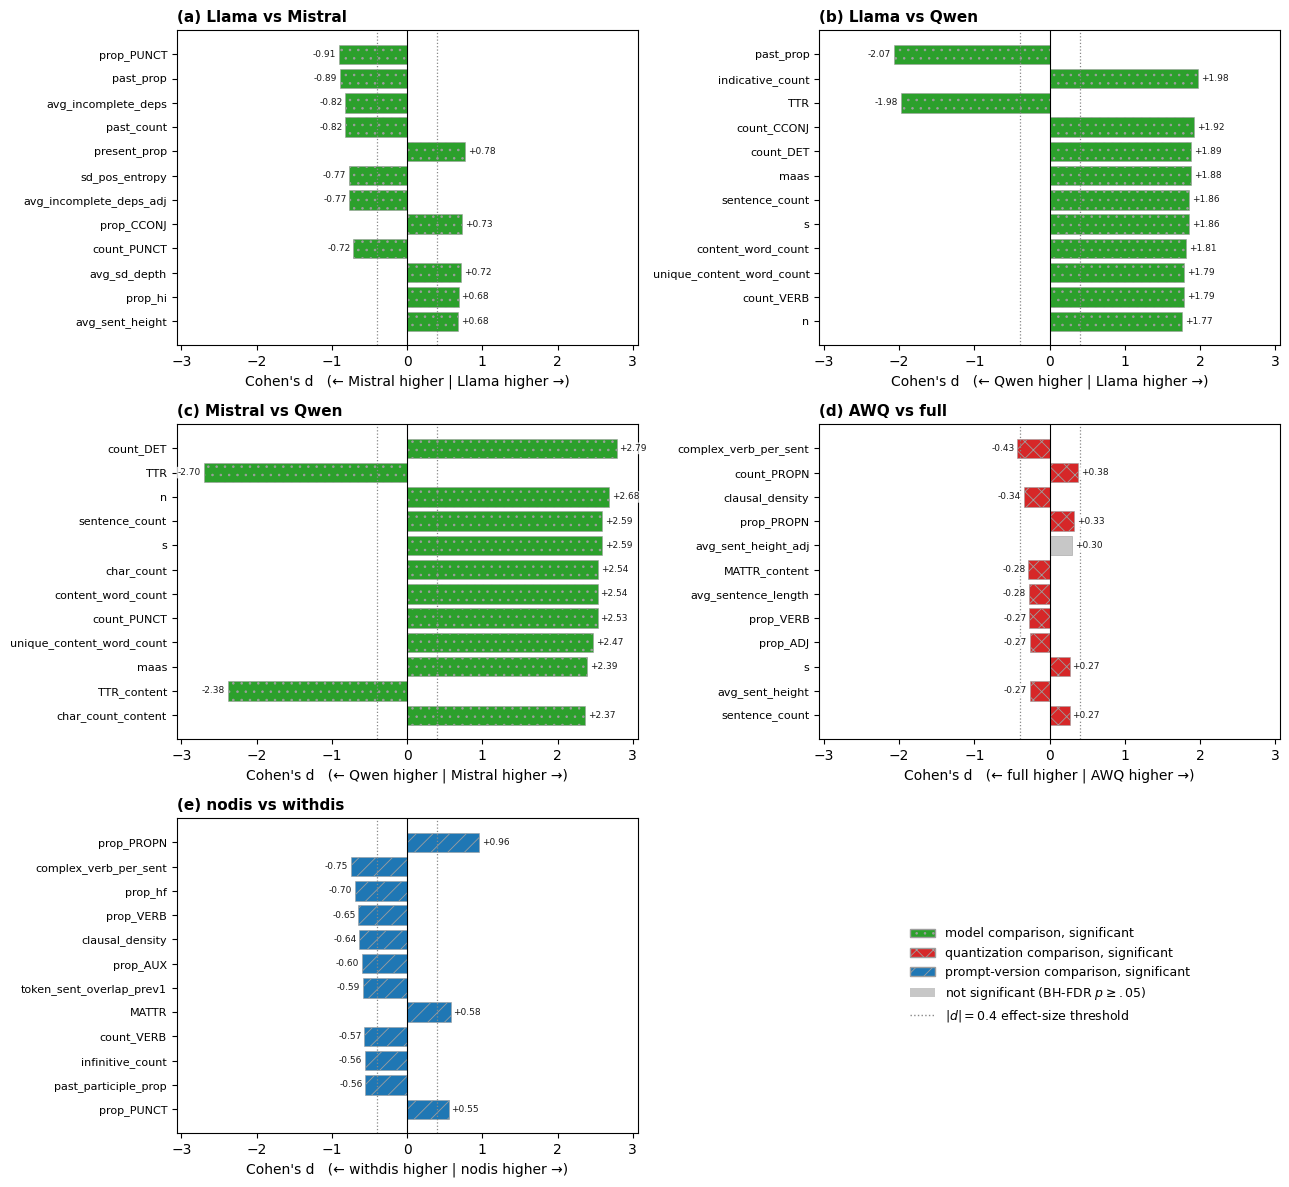

In [41]:


# thesis vocabulary, not implementation details
LABEL_MAP = {True: "withdis", False: "nodis",
             "torch": "full", "awq": "AWQ",
             "llama": "Llama", "mistral": "Mistral", "qwen": "Qwen"}
NONSIG_COLOR = "#c7c7c7"
D_THRESH = 0.4

def nice(v):
    return LABEL_MAP.get(v, str(v))

def plot_top_effects(df_stats, comparison, top_n=12, ax=None, letter="", xlim=None):
    """Top-n features by |Cohen's d| for one comparison. Positive d = group_1 higher.
    Significant bars carry the comparison's colour + light-grey texture;
    non-significant bars are plain grey. Labels get a white halo."""
    sub = df_stats[df_stats["comparison"] == comparison]
    top = sub.reindex(sub["cohen_d"].abs()
                      .sort_values(ascending=False).index).head(top_n)[::-1]
    g1, g2 = nice(sub["group_1"].iloc[0]), nice(sub["group_2"].iloc[0])
    if ax is None:
        fig, ax = plt.subplots(figsize=(7, 0.38 * top_n + 1.5))

    gv = sub["grouping_var"].iloc[0]
    group_color = GROUPVAR_COLOR[gv]
    colors = [group_color if sig else NONSIG_COLOR for sig in top["reject_H0"]]
    bars = ax.barh(top["feature"], top["cohen_d"], color=colors,
                   edgecolor=HATCH_COLOR, linewidth=0.4)
    for patch, sig in zip(bars, top["reject_H0"]):
        patch.set_hatch(GROUPVAR_HATCH[gv] if sig else "")

    # exact d at the end of each bar, in a white halo
    ax.bar_label(bars, labels=[f"{d:+.2f}" for d in top["cohen_d"]],
                 fontsize=6.5, padding=2, color="#1a1a1a", bbox=LABEL_BBOX)

    # zero line + emphasized effect-size threshold (common ruler across panels)
    ax.axvline(0, color="black", linewidth=0.8)
    for v in (-D_THRESH, D_THRESH):
        ax.axvline(v, color="#888", linewidth=0.9, linestyle=":")

    # symmetric limits -> zero centered, direction comparison honest within panel
    m = xlim if xlim is not None else top["cohen_d"].abs().max() * 1.25
    ax.set_xlim(-m, m)

    ax.set_xlabel(f"Cohen's d   (\u2190 {g2} higher | {g1} higher \u2192)")
    ax.set_title(f"({letter}) {g1} vs {g2}", fontsize=11,
                 fontweight="bold", loc="left")
    ax.tick_params(axis="y", labelsize=8)
    return ax


comparisons = df_stats["comparison"].unique()
ncols = 2
nrows = int(np.ceil(len(comparisons) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(13, 4.2 * nrows))

def top_abs(sub, top_n=12):
    return sub["cohen_d"].abs().sort_values(ascending=False).head(top_n).max()

global_m = max(top_abs(df_stats[df_stats["comparison"] == c]) for c in comparisons) * 1.1
for i, (ax, comp) in enumerate(zip(axes.flat, comparisons)):
    plot_top_effects(df_stats, comp, top_n=12, ax=ax, letter="abcdefgh"[i], xlim=global_m)


# use the empty slot for a figure-level legend instead of wasting it
spare = axes.flat[len(comparisons):]
for ax in spare:
    ax.axis("off")

handles = [Patch(fc=GROUPVAR_COLOR["model"], hatch=GROUPVAR_HATCH["model"], ec=HATCH_COLOR,
                 label="model comparison, significant"),
           Patch(fc=GROUPVAR_COLOR["quant"], hatch=GROUPVAR_HATCH["quant"], ec=HATCH_COLOR,
                 label="quantization comparison, significant"),
           Patch(fc=GROUPVAR_COLOR["disability_in_prompt"], hatch=GROUPVAR_HATCH["disability_in_prompt"],
                 ec=HATCH_COLOR, label="prompt-version comparison, significant"),
           Patch(fc=NONSIG_COLOR, label="not significant (BH-FDR $p \\geq .05$)"),
           Line2D([0], [0], color="#888", ls=":", lw=1,
                  label=f"$|d| = {D_THRESH}$ effect-size threshold")]
if len(spare):
    spare[0].legend(handles=handles, loc="center", fontsize=9, frameon=False)
else:
    fig.legend(handles=handles, loc="lower center", ncol=3, fontsize=9, frameon=False)

save_show("complexity_top_effects.pdf", rect=[0, 0, 1, 0.95])